# 🏥 Disease Prediction System using Machine Learning

## 🎯 Objective
Predict diseases based on symptoms and understand key factors influencing predictions.

This project also aims to provide meaningful insights for healthcare decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
df=pd.read_csv("/kaggle/input/datasets/itachi9604/disease-symptom-description-dataset/dataset.csv")
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(df.shape)
df.info()

(4920, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB


In [4]:
df.columns

Index(['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4',
       'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9',
       'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14',
       'Symptom_15', 'Symptom_16', 'Symptom_17'],
      dtype='object')

In [5]:
df['Disease'].value_counts()

Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hepat

<Axes: xlabel='Disease'>

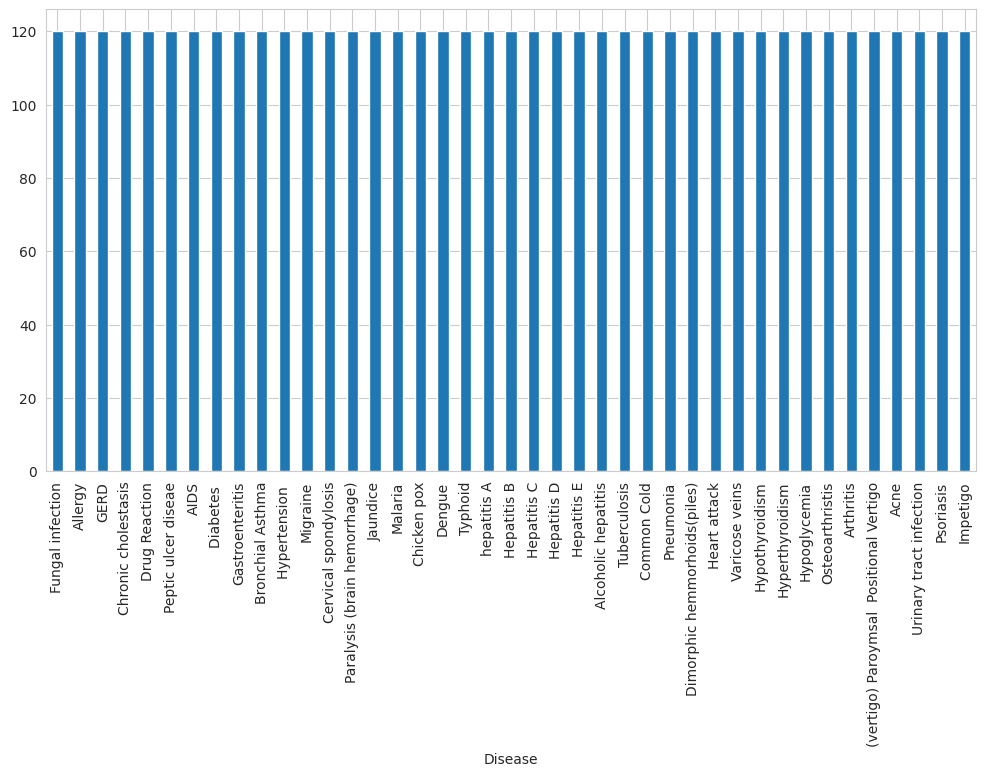

In [6]:
plt.figure(figsize=(12,6))

df['Disease'].value_counts().plot(kind='bar')


## ⚙️ Data Cleaning & Feature Engineering

Converting symptom columns into binary features suitable for machine learning models.

In [7]:
df.columns = df.columns.str.strip()

In [8]:
target_col = df.columns[0]
symptom_cols = df.columns[1:]

In [9]:
df[symptom_cols] = df[symptom_cols].fillna(0)

In [10]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

symptom_lists = df[symptom_cols].apply(
    lambda row: [sym for sym in row if sym != 0],
    axis=1
)

x = pd.DataFrame(mlb.fit_transform(symptom_lists), columns=mlb.classes_)

In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df[target_col])

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
print(x_train.shape)
print(x_test.shape)

(3936, 131)
(984, 131)


## 📊 Insight

- Symptom data was transformed into binary features using one-hot encoding  
- Each symptom now acts as an independent feature  
- Dataset is now suitable for machine learning models  

## 🤖 Baseline Models
Training machine learning models to predict diseases based on symptoms.

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report

dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

dt_preds=dt.predict(x_test)

In [15]:
dt_acc = accuracy_score(y_test, dt_preds)

print("Decision Tree Accuracy:", dt_acc)
print(classification_report(y_test, dt_preds))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        24
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        24
           9       1.00      1.00      1.00        24
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        24
          16       1.00      1.00      1.00        24

## ⚠️ Important Observation

The dataset shows near-perfect separability between diseases based on symptoms, leading to very high accuracy.

This indicates that the model is learning deterministic patterns rather than generalizing from noisy real-world data.

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42,
)

rf.fit(x_train,y_train)
rf_preds=rf.predict(x_test)

In [17]:
rf_acc=accuracy_score(y_test,rf_preds)

print('Random Forest Accuracy',rf_acc)
print(classification_report(y_test,rf_preds))

Random Forest Accuracy 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        24
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        24
           9       1.00      1.00      1.00        24
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        24
          16       1.00      1.00      1.00        24


In [18]:
results=pd.DataFrame({
    'Model':['Decision Tree','Random Forest'],
    'Accuracy':[dt_acc,rf_acc]
})
results

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0


## 📊 Model Performance Insight

Both models achieved very high accuracy due to the structured and deterministic nature of the dataset.

Each disease corresponds to a unique combination of symptoms, making the classification task relatively straightforward.

This level of performance is unlikely in real-world healthcare data, where symptoms often overlap and contain noise.

## 🚀 Advanced Model — XGBoost

Using XGBoost to validate model performance and analyze feature importance.

In [19]:
from xgboost import XGBClassifier

xgb=XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:43:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
xgb_preds=xgb.predict(x_test)

In [21]:
from sklearn.metrics import accuracy_score

xgb_acc=accuracy_score(y_test,xgb_preds)
print('XGB accuracy:',xgb_acc)

XGB accuracy: 1.0


In [22]:
results=pd.DataFrame({
    'Model':['Decision Tree','Random Forest','XGBoost'],
    'Accuracy':[dt_acc,rf_acc,xgb_acc]
})

results

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0
2,XGBoost,1.0


## 📊 Model Comparison Insight

All models achieve near-perfect accuracy due to the deterministic nature of the dataset.

XGBoost does not significantly outperform simpler models, indicating that the problem is already easily separable.

In [23]:
importances=xgb.feature_importances_
indices=np.argsort(importances)[-15:]

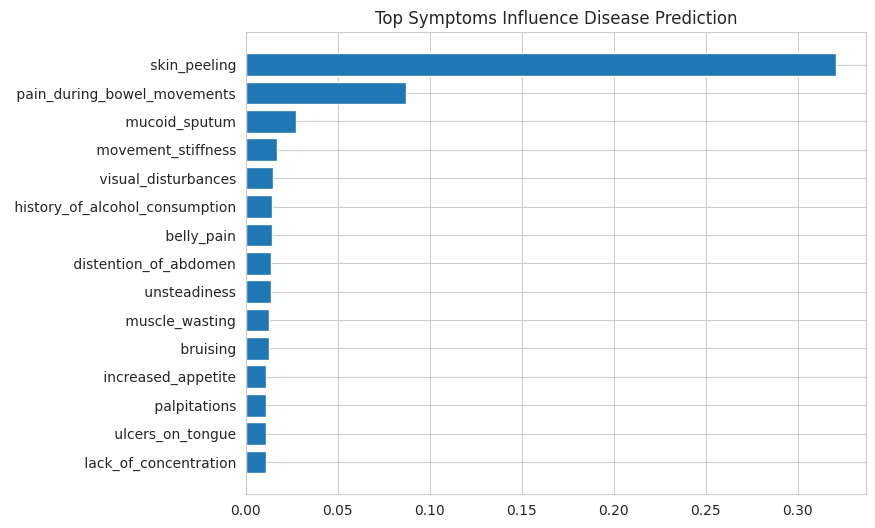

In [24]:
plt.figure(figsize=(8,6))

plt.barh(
    range(len(indices)),
    importances[indices]
)
plt.yticks(
    range(len(indices)),
    x.columns[indices]
)

plt.title("Top Symptoms Influence Disease Prediction")
plt.show()

XGBoost confirms that symptom-based disease classification in this dataset is highly predictable.

The model highlights key symptoms that strongly influence disease prediction, which can be useful for building explainable healthcare systems.

## 🧠 Feature Importance & Medical Insights

Understanding which symptoms contribute most to disease prediction.

In [25]:
important_features=pd.DataFrame({
    "Symptom":x.columns,
    "Importance":xgb.feature_importances_
}).sort_values(by='Importance',ascending=False)

important_features.head(10)

,Symptom,Importance
98,skin_peeling,0.320904
75,pain_during_bowel_movements,0.086968
66,mucoid_sputum,0.027390
65,movement_stiffness,0.017107
119,visual_disturbances,0.014691
47,history_of_alcohol_consumption,0.014055
7,belly_pain,0.013977
33,distention_of_abdomen,0.013485
118,unsteadiness,0.013423
68,muscle_wasting,0.012811


## 📊 Key Observations

- Certain symptoms strongly influence predictions  
- Some diseases are highly distinguishable due to unique symptom patterns  
- Feature importance helps identify critical indicators for diagnosis  

In [26]:
desc=pd.read_csv("/kaggle/input/datasets/itachi9604/disease-symptom-description-dataset/symptom_Description.csv")
desc.head()

,Disease,Description
0,Drug Reaction,An adverse drug reaction (ADR) is an injury ca...
1,Malaria,An infectious disease caused by protozoan para...
2,Allergy,An allergy is an immune system response to a f...
3,Hypothyroidism,"Hypothyroidism, also called underactive thyroi..."
4,Psoriasis,Psoriasis is a common skin disorder that forms...


In [27]:
desc_dict=dict(zip(desc['Disease'],desc['Description']))

desc_dict[list(desc_dict.keys())[0]]

'An adverse drug reaction (ADR) is an injury caused by taking medication. ADRs may occur following a single dose or prolonged administration of a drug or result from the combination of two or more drugs.'

In [28]:
prec=pd.read_csv("/kaggle/input/datasets/itachi9604/disease-symptom-description-dataset/symptom_precaution.csv")
prec.head()

,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths


In [29]:
prec_dict={}

for _, row in prec.iterrows():
    prec_dict[row['Disease']]=[
        row['Precaution_1'],
        row['Precaution_2'],
        row['Precaution_3'],
        row['Precaution_4']
    ]

In [30]:
def predict_disease(symptom_list):
    input_data=[1 if col in symptom_list else 0 for col in x.columns]

    pred=xgb.predict([input_data])[0]

    disease=encoder.inverse_transform([pred])[0]

    description=desc_dict.get(disease,"No description available")
    precautions=prec_dict.get(disease,[])

    return disease,description,precautions

In [31]:
symptoms=['itching','skin_rash']

disease,description,precautions=predict_disease(symptoms)

print('Predicted Disease:',disease)
print('Description:',description)
print('Precautions:',precautions)

Predicted Disease: Fungal infection
Description: In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in the human body. Like many microbes, there are helpful fungi and harmful fungi.
Precautions: ['bath twice', 'use detol or neem in bathing water', 'keep infected area dry', 'use clean cloths']


## 💼 Real-World Impact

This system demonstrates how machine learning can assist in:

- Early disease detection  
- Decision support for healthcare professionals  
- Providing precautionary guidance to patients  

Such systems can be extended into web or mobile applications for real-time usage.

## 📌 Conclusion

- Machine learning can effectively predict diseases based on symptoms  
- Dataset structure leads to high accuracy due to deterministic patterns  
- Feature importance enables explainability in healthcare systems  
- Integration with descriptions and precautions transforms the model into a practical decision-support system  

In [32]:
import pickle

pickle.dump({
    "model": xgb, 
    "encoder": encoder,
    "features": x.columns.tolist(),
    "desc": desc_dict,
    "prec": prec_dict
}, open("model.pkl", "wb"))